- Part(a) Graphs using c++ 

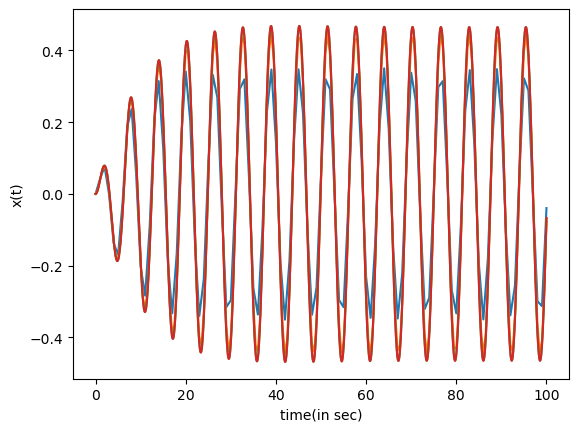

In [7]:
import numpy as np
import matplotlib.pyplot as plt

filename = ["Ode_sachin_0.txt", "Ode_sachin_1.txt", "Ode_sachin_2.txt", "Ode_sachin_3.txt"]

for i in range(len(filename)):
    data = np.loadtxt(filename[i])
    t = data[:, 0]
    x = data[:, 1]
    v = data[:, 2]

    plt.plot(t, x)
    plt.xlabel("time(in sec)")
    plt.ylabel("x(t)")

# Display the plot
plt.show()


- Part (a) using python

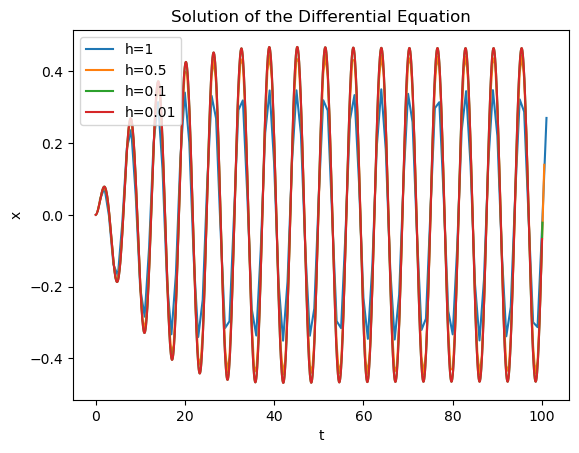

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def dv_dt(t, x, v):
    P = 0.1
    gamma = 0.5
    zeta = 0.2
    omega = 1
    return P*np.cos(omega*t) - zeta*v - x - gamma*np.power(x, 3)

H = [1, 0.5, 0.1, 0.01]

for i in range(len(H)):
    h = H[i]
    t = 0
    x = 0
    v = 0
    T = 100

    t_values = []
    x_values = []
    v_values = []

    while t <= T:
        kx1 = v
        kv1 = dv_dt(t, x, v)

        kx2 = v + h*kv1/2
        kv2 = dv_dt(t + h/2, x + h*kx1/2, v + h*kv1/2)

        kx3 = v + h*kv2/2
        kv3 = dv_dt(t + h/2, x + h*kx2/2, v + h*kv2/2)

        kx4 = v + h*kv2
        kv4 = dv_dt(t + h, x + h*kx2, v + h*kv2)

        x = x + (h/6)*(kx1 + 2*kx2 + 2*kx3 + kx4)
        v = v + (h/6)*(kv1 + 2*kv2 + 2*kv3 + kv4)
        t = t + h

        t_values.append(t)
        x_values.append(x)
        v_values.append(v)

    plt.plot(t_values, x_values, label=f"h={h}")

# Add labels and title
plt.xlabel("t")
plt.ylabel("x")
plt.title("Solution of the Differential Equation")

# Add a legend
plt.legend()

# Display the plot
plt.show()


- Part c

ac = -0.12041222129180511
as = 0.5789483357806652


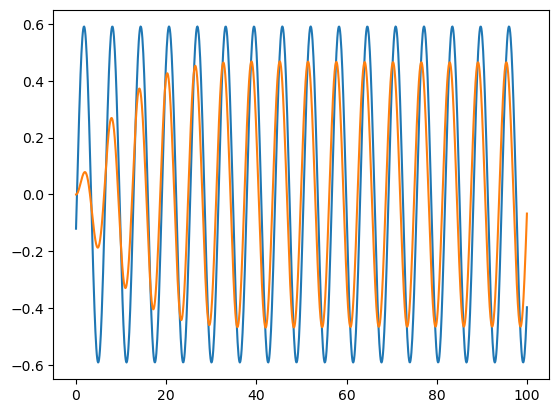

In [25]:
import numpy as np
from scipy.optimize import fsolve

def equations(variables):
    ac, as_value = variables
    omega = 1
    zeta = 0.2
    gamma = 0.5
    P = 0.1
    t = 0.0
    equation1 = (1 - omega**2) * ac + zeta * omega * as_value + (3/4) * gamma * (ac**3 + ac * as_value**2) - P
    equation2 = (1 - omega**2) * as_value - zeta * omega * ac + (3/4) * gamma * (as_value**3 + ac**2 * as_value) - P
    return [equation1, equation2]

# Initial guess for the variables
initial_guess = [1.0, 1.0]

# Solve the system of equations
solution = fsolve(equations, initial_guess)

# Print the solution
ac_solution, as_solution = solution
print("ac =", ac_solution)
print("as =", as_solution)


t_new = np.linspace(0, 100, 1000)
x_new = ac_solution*np.cos(t) + as_solution*np.sin(t)
plt.plot(t_new, x_new)
plt.plot(t_values, x_values)
